# **Problem Statement**

## Business Context


In hazardous workplaces like construction sites and industrial plants, ensuring worker safety is critical. Head injuries caused by falling objects or accidents are among the leading causes of fatalities. Safety helmets are essential protective equipment, yet compliance with helmet regulations is often inconsistent, particularly in large-scale operations where manual monitoring is inefficient and prone to errors.

SafeGuard Corp aims to address this issue by automating safety monitoring through an advanced image analysis system. By detecting workers and identifying whether they are wearing helmets, this system will enhance compliance, minimize workplace injuries, and reduce human oversight errors.

## Objective

Given the challenges faced by SafeGuard Corp in ensuring helmet compliance at hazardous workplaces, they have hired you as a Data Scientist to develop an advanced, machine learning-based solution that achieves the following:

1. Utilize object detection techniques to accurately identify and locate workers in images captured from construction sites and industrial plants.

2. Implement a classification model that distinguishes whether the detected workers are wearing helmets or not.

3. Analyze patterns in the collected image data to understand the factors influencing helmet compliance and the common scenarios where lapses occur.

4. Integrate the system with existing safety protocols to provide real-time alerts and reports to safety officers, enabling prompt corrective actions.

5. Ensure the solution is scalable to handle increased volumes of image data from multiple sites, while maintaining high accuracy and efficiency.

This automated system aims to enhance compliance, reduce the risk of head injuries, and streamline the monitoring process, ultimately leading to a safer workplace environment.

## Data Description

The dataset consists of 640 images, equally divided into two categories:
1. WithHelmet: 320images showing workers wearing helmets.
2. WithoutHelmet: 320images showing workers not wearing helmets.

**Dataset Characteristics:**
1. Variations in Conditions: Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
2. WorkerActivities: Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Please read the instructions carefully before starting the project.**
This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.

# **Importing Necessary Libraries**

In [1]:
#import nescessary libraries
import cv2 as cv
import torch
from PIL import Image, ImageDraw
import tensorflow as tf
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import numpy as np
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **Loading the Data**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from zipfile import ZipFile

# Path to the zip file

zip_file_path = '/content/drive/MyDrive/Walsh/3 - Computer Vision/Project CV/HelmetDetectionDataset.zip' # Provide the correct path of the zip file

# Destination folder to extract files
extract_to_path = '/content/drive/MyDrive/Walsh/3 - Computer Vision/Project CV/unzip'

# Unzipping the file
with ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

print(f'File unzipped successfully to {extract_to_path}')

File unzipped successfully to /content/drive/MyDrive/Walsh/3 - Computer Vision/Project CV/unzip


In [4]:
training_data_images_path = extract_to_path + '/HelmetDetectionDataset/Training/'
validation_data_images_path = extract_to_path + '/HelmetDetectionDataset/Validation/'

# **Exploratory Data Analysis**


1. **Class Distribution Analysis**: This step involves examining how the different classes are distributed across the dataset. For instance, in a helmet detection task, you would check the number of images with people wearing helmets versus those without. This helps identify if there are any imbalances that might affect model performance.

2. **Visualizing Sample Images**: In this phase, we take a closer look at some of the images from the dataset. This could include displaying random samples or specific examples from each class. Visualizations help to understand the quality, diversity, and challenges in the data (e.g., lighting, posture, background, etc.), which is important for choosing the right model and preprocessing techniques.

In [5]:
training_images_with_helmet = len(os.listdir(os.path.join(training_data_images_path, 'WorkersWithHelmet')))
training_images_without_helmet = len(os.listdir(os.path.join(training_data_images_path, 'WorkersWithoutHelmet')))
validation_images_with_helmet = len(os.listdir(os.path.join(validation_data_images_path, 'WorkersWithHelmet')))
validation_images_without_helmet = len(os.listdir(os.path.join(validation_data_images_path, 'WorkersWithHelmet')))

categories = ['Train With Helmet', 'Train Without Helmet', 'Validation With Helmet', 'Validation Without Helmet']
values = [training_images_with_helmet, training_images_without_helmet, validation_images_with_helmet, validation_images_without_helmet]

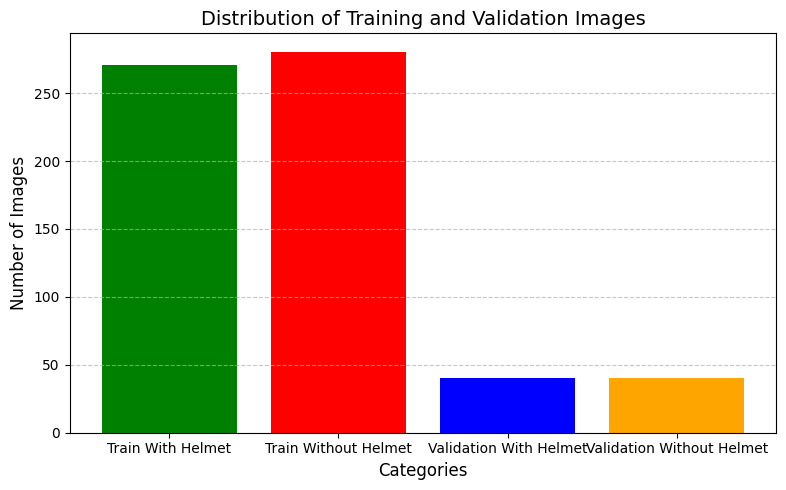

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(categories, values, color=['green', 'red', 'blue', 'orange'])

# Adding titles and labels
plt.title('Distribution of Training and Validation Images', fontsize=14)
plt.xlabel('Categories', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

Let's view some random images from the training dataset.

In [7]:
# Function to plot random images
def plot_random_images(folder_path, title, num_images=5):
    # Get all image file names from the folder
    image_files = os.listdir(folder_path)
    # Randomly select the specified number of images
    selected_images = random.sample(image_files, num_images)

    # Plot the images
    plt.figure(figsize=(15, 5))
    for i, image_file in enumerate(selected_images):
        image_path = os.path.join(folder_path, image_file)
        img = mpimg.imread(image_path)
        plt.subplot(1, num_images, i + 1)  # Arrange images in 1 row
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        plt.title(f'{title} #{i + 1}', fontsize=10)

    plt.tight_layout()
    plt.show()

In [8]:
# Paths to the folders
with_helmet_path_training = os.path.join(training_data_images_path, 'WorkersWithHelmet')
without_helmet_path_training = os.path.join(training_data_images_path, 'WorkersWithoutHelmet')
with_helmet_path_validation = os.path.join(validation_data_images_path, 'WorkersWithHelmet')
without_helmet_path_validation = os.path.join(validation_data_images_path, 'WorkersWithoutHelmet')

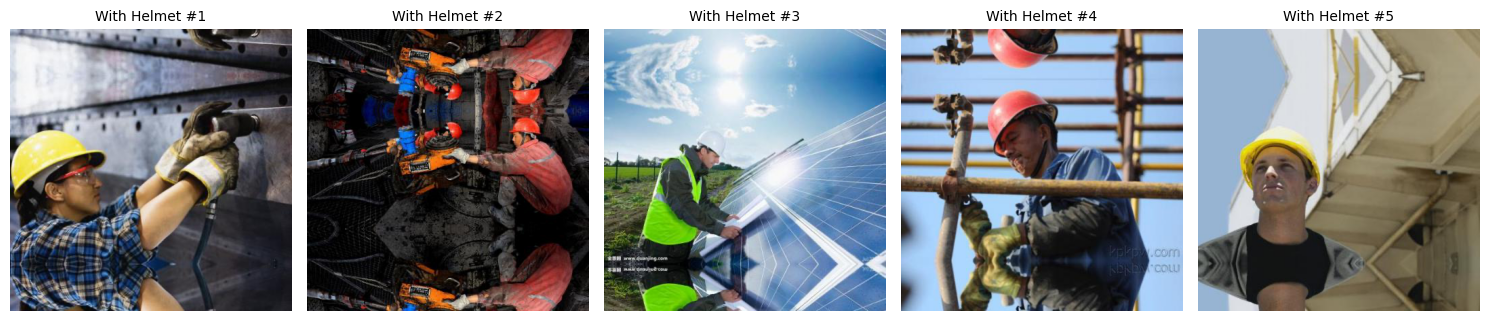

In [9]:
# Plot 5 random images with helmet
plot_random_images(with_helmet_path_training, 'With Helmet', num_images=5) # Complete the code such that it plots images of "with helmet" from the training/Validation data.

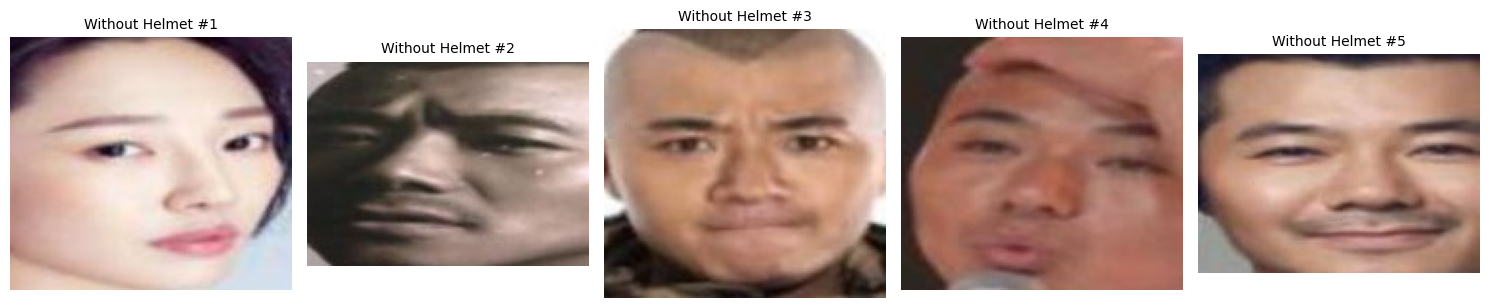

In [10]:
plot_random_images(without_helmet_path_training, 'Without Helmet', num_images=5) # Complete the code such that it plots images of "with helmet" from the training/Validation data.

# **Object Detection**


1. We have developed a function, **detect_and_count_persons**, that leverages the YOLOv5 model to detect and create bounding boxes around all identified persons in the image. This function returns the bounding boxes along with the confidence scores for each detection.

2. The results from YOLOv5 are then passed to another function, **crop_person_images**. This function extracts and crops individual images of persons based on the bounding boxes provided by YOLO. We have set a confidence threshold of 0.70, meaning that only detections with a confidence score above 0.70 are considered valid. This helps eliminate false positives, ensuring only reliable detections are used for further processing.

3. Once we have the cropped images, we apply several augmentation techniques to increase the diversity of the dataset and make the model more robust.

In [11]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.4 MB/s eta 0:00:00


In [12]:
#Load the yolov5 model
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')  # Complete the code such that it loads "yolov5s for object detection"

/usr/local/lib/python3.12/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/ultralytics/yolov5/zipball/master" to /root/.cache/torch/hub/master.zip
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 2025-11-15 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

100%|██████████| 14.1M/14.1M [00:00<00:00, 105MB/s] 

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [13]:
def detect_and_count_persons(model, image_path, show_image=False):
    """
    Function to detect and count the number of persons in an image.
    - Displays the original image.
    - Prints the count of persons detected.
    - Shows the image with bounding boxes drawn.

    Args:
        image_path (str): Path to the input image.
    """
    # Perform inference
    results = model(image_path)

    # Extract predictions
    detections = results.xyxy[0]  # Get bounding boxes in xyxy format
    person_count = 0

    # Iterate over detections and count 'person' labels (class 0 in COCO)
    for detection in detections:
        class_id = int(detection[5])  # Class ID is in the 6th position (zero-indexed)
        if class_id == 0 and 0.60 < detection[4]:  # 'person' class in COCO
            person_count += 1

    # Print the count of persons detected
    print(f"Number of persons detected: {person_count}")

    # Display the original image
    if show_image:
      original_image = Image.open(image_path)
      plt.figure(figsize=(10, 8))
      plt.imshow(original_image)
      plt.axis('off')
      plt.title('Original Image')
      plt.show()

      # Display the image with bounding boxes
      print("Displaying image with bounding boxes:")
      results.show()  # Shows images with bounding box

    return results

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


Number of persons detected: 1
Displaying image with bounding boxes:


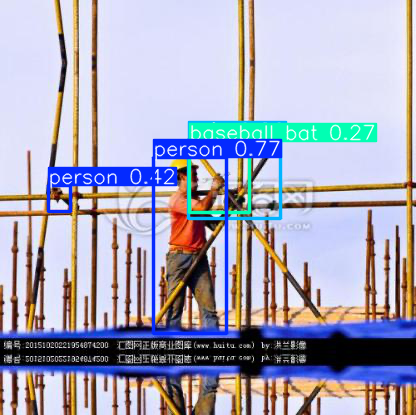

In [14]:
# detect people in an image and plot the image with the corresponding bounding boxes
img_path = os.path.join(with_helmet_path_training, os.listdir(with_helmet_path_training)[1])
results = detect_and_count_persons(model, img_path, show_image= True)

Number of persons detected: 0
Displaying image with bounding boxes:


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


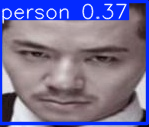

In [15]:
img_path_2 = os.path.join(without_helmet_path_training, os.listdir(without_helmet_path_training)[4])
results_2 = detect_and_count_persons(model, img_path_2, True) # Complete the code such that it detects people in an image and plots the image with the corresponding bounding boxes

In [16]:
def crop_person_images(image_path, results, confidence_threshold=0.60):
    """
    Crops images of persons detected by YOLOv5.
    Only crops persons with a confidence score greater than the threshold.

    Args:
        image_path (str): Path to the input image.
        results (YOLO result object): The result object from YOLO inference.
        confidence_threshold (float): Minimum confidence value for cropping persons. Default is 0.80.

    Returns:
        List of PIL Image: List of cropped images of persons detected.
    """
    # Open the original image
    original_image = Image.open(image_path)

    # Extract predictions (xyxy format: [x1, y1, x2, y2, confidence, class_id])
    detections = results.xyxy[0]
    cropped_images = []

    # Iterate over detections and crop images for 'person' class with high confidence
    for detection in detections:
        x1, y1, x2, y2, confidence, class_id = detection.tolist()
        class_id = int(class_id)

        if class_id == 0 and confidence > confidence_threshold:
            # Crop the image based on the bounding box coordinates
            cropped_image = original_image.crop((x1, y1, x2, y2))
            cropped_images.append(cropped_image)

    return cropped_images


# **Dataset Creation for Image Classification**






1. For the helmet detection task, we begin by storing the cropped images of individuals, which are extracted from the original image using the YOLO algorithm. Along with each cropped image, we also store the corresponding label indicating whether the person is wearing a helmet or not. This label serves as the ground truth for training the model.

2. To ensure consistency in the dataset, we preprocess the cropped images by resizing them to the same dimensions, typically the input size required by the model (e.g., 224x224 for ResNet) and rescaling it by dividing the pixel values by 255. This step ensures that all input images have uniform size, which is crucial for feeding them into the neural network.

In [17]:
# Creating the dataset from the images -
# Complete the function below to generate our dataset.
def dataset_generator(with_helmet_path, without_helmet_path):

  dataset = []

  all_helmet_images_name = os.listdir(with_helmet_path)
  all_non_helmet_images_name = os.listdir(without_helmet_path)

  for helmet_image_name in all_helmet_images_name:
    image_path = os.path.join(with_helmet_path, helmet_image_name)
    results = detect_and_count_persons(model, image_path=image_path)
    cropped_images = crop_person_images(image_path, results) # Complete the code such that the image is cropped based on the detection results.

    for croped_image in cropped_images:
      dataset.append([croped_image, 1])

  for non_helmet_image_name in all_non_helmet_images_name:
    img_path = os.path.join(without_helmet_path, non_helmet_image_name)
    original_image = Image.open(img_path)
    dataset.append([original_image, 0])

  return dataset

In [18]:
train_dataset = dataset_generator(with_helmet_path_training,without_helmet_path_training)
validation_dataset = dataset_generator(with_helmet_path_validation, without_helmet_path_validation)

Number of persons detected: 1
Number of persons detected: 1


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.am

Number of persons detected: 1
Number of persons detected: 1
Number of persons detected: 1
Number of persons detected: 0
Number of persons detected: 0


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.am

Number of persons detected: 1
Number of persons detected: 1
Number of persons detected: 1
Number of persons detected: 2
Number of persons detected: 1


...

/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.am

Number of persons detected: 1
Number of persons detected: 1
Number of persons detected: 0
Number of persons detected: 1
Number of persons detected: 0
Number of persons detected: 1


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.am

Number of persons detected: 0
Number of persons detected: 0
Number of persons detected: 0
Number of persons detected: 0
Number of persons detected: 0
Number of persons detected: 1
Number of persons detected: 1
Number of persons detected: 0
Number of persons detected: 1


/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/root/.cache/torch/hub/ultralytics_yolov5_master/models/common.py:898: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


In [19]:
# A function to preprocess the images

def transform_image(image):
    img = image.convert('RGB')  # Complete the code such that the image is in RGB format
    img = img.resize((224, 224))  # Complete the code such that the image is Resized to (ResNet input size)

    # Convert image to numpy array
    img = np.array(img) / 255.0  # Normalize pixel values to the range [0, 1]
    return img

In [20]:
def process_images_and_labels(data):
    images = []
    labels = []

    for image, label in data:
        img = transform_image(image)
        images.append(img)
        labels.append(label)

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

In [21]:
train_processed_images, train_labels = process_images_and_labels(train_dataset) # Train dataset is processed.
validation_processed_images, validation_labels = process_images_and_labels(validation_dataset) # Complete the code such that the validation dataset is processed.

In [22]:
#spliting the training dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(train_processed_images , train_labels, test_size=0.1, random_state=42,stratify=train_labels) #Complete the code such that The train dataset is split into train and test and the labels are stratified.
X_val , y_val = validation_processed_images, validation_labels

print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(446, 224, 224, 3) (446,)
(65, 224, 224, 3) (65,)
(50, 224, 224, 3) (50,)


# **Image Classification**

In this step, we will load a pretrained ResNet50 model that has already been trained on a large and diverse dataset, such as ImageNet.

- ResNet50 is a deep convolutional neural network known for its residual connections, which allow it to efficiently train very deep networks without the problem of vanishing gradients.
- This architecture is widely used for tasks such as image classification, and it can be fine-tuned to recognize specific objects, like helmets, in our case.

## Utility Function

In [23]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    predictions = np.round(model.predict(predictors)).flatten()

    # Calculate precision and recall
    accuracy = accuracy_score(target, predictions)
    precision = precision_score(target, predictions)
    recall = recall_score(target, predictions)
    f1 = f1_score(target, predictions)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": accuracy, "Recall": recall, "Precision": precision, "F1 Score": f1,},
        index=[0],
    )

    return df_perf

## Model 1 ( Base model + output layer)

In [24]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-10]:
    layer.trainable = False  # Complete the code such that all the layers are freezed except for the last 10.

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [25]:
model = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Complete the code with appropriate number of output neurons.
])

# 7. Compile the model

model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),  # Complete the code with Adam optimizer and learning rate = 0.001
              loss='binary_crossentropy',
              metrics=['accuracy'])  # Complete the code using appropriate metric.

In [26]:
train_datagen = ImageDataGenerator()

In [27]:
#Train the model
epochs = 10
# Batch size
batch_size = 32

history_model_1 = model.fit(train_datagen.flow(X_train,y_train,
                                       shuffle= False),
                    epochs= epochs,
                    batch_size = batch_size,
                    validation_data=(X_val,y_val),
                    verbose=1)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7829 - loss: 0.4233 - val_accuracy: 0.3846 - val_loss: 7.2073
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9614 - loss: 0.0813 - val_accuracy: 0.5231 - val_loss: 1.6129
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.9950 - loss: 0.0448 - val_accuracy: 0.8923 - val_loss: 0.3678
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.9708 - loss: 0.0576 - val_accuracy: 0.9846 - val_loss: 0.1478
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - accuracy: 0.9907 - loss: 0.0339 - val_accuracy: 0.8769 - val_loss: 0.4439
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9959 - loss: 0.0127 - val_accuracy: 0.7077 - val_loss: 2.3380
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.9992 - loss: 0.0102 - val_accuracy: 0.9692 - val_loss: 0.0931
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 0.75

Evaluating Model performance on training and validation data.



In [28]:
model_perf_df_val = model_performance_classification(model, X_val, y_val)
model_perf_df_val

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


,Accuracy,Recall,Precision,F1 Score
0,0.923077,1.0,0.833333,0.909091


In [29]:
model_perf_df_train = model_performance_classification(model, X_train, y_train) # Complete the code such that the model is evaluated on Training data.
model_perf_df_train

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 210ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.941704,1.0,0.881818,0.937198


lets plot the training accuracy and validation accuracy against the epochs.

In [30]:
history_model_1.history['val_accuracy']

[0.38461539149284363,
 0.5230769515037537,
 0.892307698726654,
 0.9846153855323792,
 0.8769230842590332,
 0.7076923251152039,
 0.9692307710647583,
 0.7538461685180664,
 0.5076923370361328,
 0.9230769276618958]

In [31]:
plt.plot(history_model_1.history['accuracy'])
plt.plot(history_model_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# **Image Classification Performance Improvement and Final Model Selection**

## Model 2: (Base model + FFN)

Lets add a Feed forward neural network with 2 hidden layers. We will be increasing the learning rate while keeping the epochs same.

In [32]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-10]:
    layer.trainable = False  # Complete the code such that it freezes all the layers except for last 10.

In [33]:
model_FFN = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'), # Complete the code by providing appropriate number of neurons for the FFN
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


model_FFN.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.001), # Complete the code with Adam optimizer and learning rate = 0.001
              loss='binary_crossentropy',
              metrics=['accuracy'])    # Complete the code with the appropriate metric.

In [34]:
epochs = 10
# Batch size
batch_size = 32

history_model_2 = model_FFN.fit(train_datagen.flow(X_train,y_train,  # Complete the code to fit the appropraite model.
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle = False),
                    epochs=epochs,
                    validation_data=(X_val,y_val),
                    verbose=1)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.7261 - loss: 0.4829 - val_accuracy: 0.9846 - val_loss: 0.1433
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - accuracy: 0.9716 - loss: 0.0610 - val_accuracy: 0.6308 - val_loss: 5.5132
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.9770 - loss: 0.0459 - val_accuracy: 0.7846 - val_loss: 1.6224
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9920 - loss: 0.0299 - val_accuracy: 0.8462 - val_loss: 0.7951
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.9861 - loss: 0.0444 - val_accuracy: 0.9231 - val_loss: 0.4025
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9961 - loss: 0.0118 - val_accuracy: 0.9538 - val_loss: 0.2881
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.9995 - loss: 0.0070 - val_accuracy: 0.6154 - val_loss: 3.2204
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.90

In [35]:
model_FFN_perf_df_val = model_performance_classification(model_FFN, X_val, y_val)
model_FFN_perf_df_val

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


,Accuracy,Recall,Precision,F1 Score
0,0.492308,1.0,0.431034,0.60241


In [36]:
model_FFN_perf_df_train = model_performance_classification(model_FFN, X_train,y_train)  # Complete the code such that Model_2's performance is evaludated on the train set.
model_FFN_perf_df_train

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.502242,1.0,0.466346,0.636066


In [37]:
plt.plot(history_model_2.history['accuracy'])
plt.plot(history_model_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Model 3 (Base model + FFN + Data Augmentation) with dropout

Lets add a dropout and data augmentation. We will also decrease the learning rate so that we can reach a global minimnum.

In [38]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-10]:
    layer.trainable = False  # Complete the code to freeze all layers except for the last 10.

In [39]:
model_FFN_DA = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Complete the code to drop out 50% of the neurons.
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


model_FFN_DA.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.0001), # Complete the code to use the Adam Optimizer and decrease the learning rate to 0.0001.
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [40]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              )  # Complete the code to add Data augmentation by rotating the images 20 degrees and adding 20% width and height.

In [41]:
epochs = 20
# Batch size
batch_size = 32

history_model_3 = model_FFN_DA.fit(train_datagen.flow(X_train,y_train,  # Complete the code to fit the appropriate model.
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle= False),
                    epochs= epochs,
                    validation_data=(X_val,y_val),
                    verbose=1)

Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7116 - loss: 0.5770 - val_accuracy: 0.3846 - val_loss: 0.6528
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 373ms/step - accuracy: 0.8797 - loss: 0.3229 - val_accuracy: 0.3846 - val_loss: 0.7567
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 484ms/step - accuracy: 0.9146 - loss: 0.2734 - val_accuracy: 0.3846 - val_loss: 0.5919
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 366ms/step - accuracy: 0.9179 - loss: 0.2229 - val_accuracy: 0.9846 - val_loss: 0.4666
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 427ms/step - accuracy: 0.9242 - loss: 0.2367 - val_accuracy: 0.7385 - val_loss: 0.5128
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 396ms/step - accuracy: 0.9359 - loss: 0.1764 - val_accuracy: 0.9846 - val_loss: 0.3968
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 368ms/step - accuracy: 0.9328 - loss: 0.1590 - val_accuracy: 0.3846 - val_loss: 0.6613
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 481ms/step - accuracy: 0.9372 - loss: 0.1438 - val_accuracy: 0.98

In [42]:
model_FFN_DA_perf_df_val = model_performance_classification(model_FFN_DA, X_val, y_val)
model_FFN_DA_perf_df_val

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


,Accuracy,Recall,Precision,F1 Score
0,0.984615,1.0,0.961538,0.980392


In [43]:
model_FFN_DA_perf_df_train = model_performance_classification(model_FFN_DA, X_train, y_train) # Complete the code to evaluate model_3's performance on training set.
model_FFN_DA_perf_df_train

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 218ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.973094,0.938144,1.0,0.968085


In [44]:
plt.plot(history_model_3.history['accuracy'])
plt.plot(history_model_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Model 4 (Using a different optimizer and reducing batch size)

We will be using the same model architecture as above, but this time we will use Stochastic Gradient Descent optimizer with a larger learning rate to compile our model. We will decrease our batch size so that we can have faster convergences and better generalization.

In [45]:
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-10]:
    layer.trainable = False # Complete the code to  Freeze all layers except the last 10 layers

In [46]:
model_FFN_DA_2 = tf.keras.models.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Complete the code to drop 50% of the neurons.
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])


model_FFN_DA_2.compile(optimizer= tf.keras.optimizers.SGD(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [47]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest',width_shift_range=0.2,height_shift_range=0.2,shear_range=0.3,zoom_range=0.4
                              ) # Complete the code to add Data augmentation by rotating the images 20 degrees and adding 20% width and height.

epochs = 20

batch_size = 16 # Decrease the batch size

history_model_4 = model_FFN_DA_2.fit(train_datagen.flow(X_train,y_train, # Complete the code to fit the appropraite model.
                                       batch_size=batch_size,
                                       seed=42,
                                       shuffle= True,
                                       ),
                    epochs= epochs,
                    validation_data=(X_val,y_val),
                    verbose=1)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 33s 695ms/step - accuracy: 0.6361 - loss: 0.6569 - val_accuracy: 0.6154 - val_loss: 0.6580
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 198ms/step - accuracy: 0.6740 - loss: 0.6207 - val_accuracy: 0.7538 - val_loss: 0.6638
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 206ms/step - accuracy: 0.7316 - loss: 0.5564 - val_accuracy: 0.3846 - val_loss: 0.6886
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.8226 - loss: 0.5062 - val_accuracy: 0.3846 - val_loss: 0.7083
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 250ms/step - accuracy: 0.8008 - loss: 0.4910 - val_accuracy: 0.3846 - val_loss: 0.7234
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step - accuracy: 0.8410 - loss: 0.4355 - val_accuracy: 0.3846 - val_loss: 0.7687
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.8457 - loss: 0.4240 - val_accuracy: 0.3846 - val_loss: 0.8238
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - accuracy: 0.8421 - loss: 0.4158 - val_accuracy: 

In [48]:
model_FFN_DA_2_perf_df_val = model_performance_classification(model_FFN_DA_2, X_val, y_val)
model_FFN_DA_2_perf_df_val

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step


,Accuracy,Recall,Precision,F1 Score
0,0.969231,0.96,0.96,0.96


In [49]:
model_FFN_DA_2_perf_df_train = model_performance_classification(model_FFN_DA_2, X_train, y_train) #Complete the code to Evaluate model_4's performance on training set
model_FFN_DA_2_perf_df_train

14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step


,Accuracy,Recall,Precision,F1 Score
0,0.959641,0.907216,1.0,0.951351


In [50]:
plt.plot(history_model_4.history['accuracy'])
plt.plot(history_model_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Model Performance Comparison and Final Model Selection

In [51]:
models_train_comp_df = pd.concat(
    [
        model_perf_df_train.T,
        model_FFN_perf_df_train.T,
        model_FFN_DA_perf_df_train.T,
        model_FFN_DA_2_perf_df_train.T,


    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Model 1: Simple",
    "Model 2: FFN",
    "Model 3: DA",
    'Model 4: SGD'
]

models_val_comp_df = pd.concat(   # Complete the code to concatenate the validation performances of all the models.
    [
        model_perf_df_val.T,
        model_FFN_perf_df_val.T,
        model_FFN_DA_perf_df_val.T,
        model_FFN_DA_2_perf_df_val.T

    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Model 1: Simple",
    "Model 2: FFN",
    "Model 3: DA",
    'Model 4: SGD'
]

In [52]:
print('PERFORMANCE OF MODELS ON THE TRAINING SET')
models_train_comp_df

PERFORMANCE OF MODELS ON THE TRAINING SET


,Model 1: Simple,Model 2: FFN,Model 3: DA,Model 4: SGD
Accuracy,0.941704,0.502242,0.973094,0.959641
Recall,1.000000,1.000000,0.938144,0.907216
Precision,0.881818,0.466346,1.000000,1.000000
F1 Score,0.937198,0.636066,0.968085,0.951351


In [53]:
print('PERFORMANCE OF MODELS ON VALIDATION SET')
models_val_comp_df

PERFORMANCE OF MODELS ON VALIDATION SET


,Model 1: Simple,Model 2: FFN,Model 3: DA,Model 4: SGD
Accuracy,0.923077,0.492308,0.984615,0.969231
Recall,1.000000,1.000000,1.000000,0.960000
Precision,0.833333,0.431034,0.961538,0.960000
F1 Score,0.909091,0.602410,0.980392,0.960000


## Model Performance Check on Test Set

I have selected model_FFN_DA as the best performing model, as it demonstrated the highest accuracy and F1 score on both the training and validation sets. This model incorporates data augmentation and dropout, which likely contributed to its robust performance.

In [54]:
best_model = model_FFN_DA # Complete the code by providing the variable name of the best performing model based on the performance on Train and validation set.

In [55]:
predictions = np.round(best_model.predict(X_test))
print(classification_report(y_test, predictions)) # Complete the code to print the classification report of X_test.

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        28
           1       1.00      0.77      0.87        22

    accuracy                           0.90        50
   macro avg       0.92      0.89      0.89        50
weighted avg       0.92      0.90      0.90        50



Lets plot the confusion matrix to gain a deeper insight.

In [56]:
#Compute Confusion Matrix
cm = confusion_matrix(y_test, predictions) # Complete the code to plot the confusion matrix.

# Confusion Matrix Labels
labels = ['Class 0 (No Helmet)', 'Class 1 (Helmet)']

# Check the content of the confusion matrix to ensure it's correct
print("Confusion Matrix:")

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, linewidths=1, linecolor='black',
            square=True)

# Add Titles and Axis Labels
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=12)
plt.ylabel('True Labels', fontsize=12)

# # Ensure the plot window is shown
plt.show()

Confusion Matrix:


Lets plot some images of the test dataset along with the predictions.

In [57]:
num_images = 5

selected_images = sample = np.array(random.sample(list(X_test), num_images)) # Complete the code to select 5 random images from the test data.

class_dict = {0: 'No Helmet Detected', 1: 'Helmet Detected'}

# Plot the images
plt.figure(figsize=(15, 5))
for i, image_file in enumerate(selected_images):
    confidence = best_model.predict(np.expand_dims(image_file, axis=0),verbose=2)
    prediction = int(np.round(confidence))
    if prediction == 0:
        confidence = (1 - confidence) * 100
    else:
        confidence = confidence[0][0] * 100
    detected_class = class_dict[prediction]
    plt.subplot(1, num_images, i + 1)  # Arrange images in 1 row
    plt.imshow(image_file)
    plt.axis('off')  # Hide axes
    plt.title(f' image #{i + 1} \nPredicted Class:{detected_class}\nConfidence:{np.round(confidence,2)}%', fontsize= 10)
plt.tight_layout()
plt.show()

1/1 - 0s - 36ms/step
1/1 - 0s - 35ms/step
1/1 - 0s - 35ms/step


/tmp/ipython-input-2149124115.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  prediction = int(np.round(confidence))


1/1 - 0s - 34ms/step
1/1 - 0s - 34ms/step


# **Actionable Insights and Recommendations**


## Insights

-


## Recommendations

-


<font size=6 color='blue'>Power Ahead!</font>
___